In [61]:
# Step 1: Import the libraries we need
# pandas/numpy -> data handling and math
# sklearn      -> preprocessing, model building, splitting and evaluation
# matplotlib   -> plotting graphs

import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
import matplotlib.pyplot as plt

In [62]:
# Step 2: Load the California housing dataset from the CSV file
housing = pd.read_csv("housing.csv")

In [63]:
# Step 3: Get a quick overview of the data
# Shows the number of rows/columns, column names, data types and non-null counts
print("Dataset Shape:", housing.shape)
print("\nDataset Information:")
housing.info()

Dataset Shape: (20640, 10)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [64]:
# Count how many values are missing (empty) in each column
print("\nMissing Values:")
print(housing.isnull().sum())


Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [65]:
# Preview the first 5 rows to see what the data looks like
print("\nFirst 5 Rows:")
print(housing.head())


First 5 Rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [66]:
# Step 4: Feature engineering - create new, more useful columns from existing ones

# Average number of rooms in each household
housing["rooms_per_household"] = (
    housing["total_rooms"] / housing["households"]
)

# Share of rooms that are bedrooms (bedrooms / total rooms)
housing["bedrooms_per_room"] = (
    housing["total_bedrooms"] / housing["total_rooms"]
)

# Average number of people living in each household
housing["population_per_household"] = (
    housing["population"] / housing["households"]
)

In [67]:
# Step 5: Group median income into 5 categories (1 = lowest, 5 = highest)
# This helps us split the data so train and test sets have a similar income mix
# (this is called stratified sampling)

housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0, 2, 4, 6, 8, np.inf],
    labels=[1, 2, 3, 4, 5]
)
housing[["median_income","income_cat"]]

,median_income,income_cat
0,8.3252,5
1,8.3014,5
2,7.2574,4
3,5.6431,3
4,3.8462,2
...,...,...
20635,1.5603,1
20636,2.5568,2
20637,1.7000,1
20638,1.8672,1


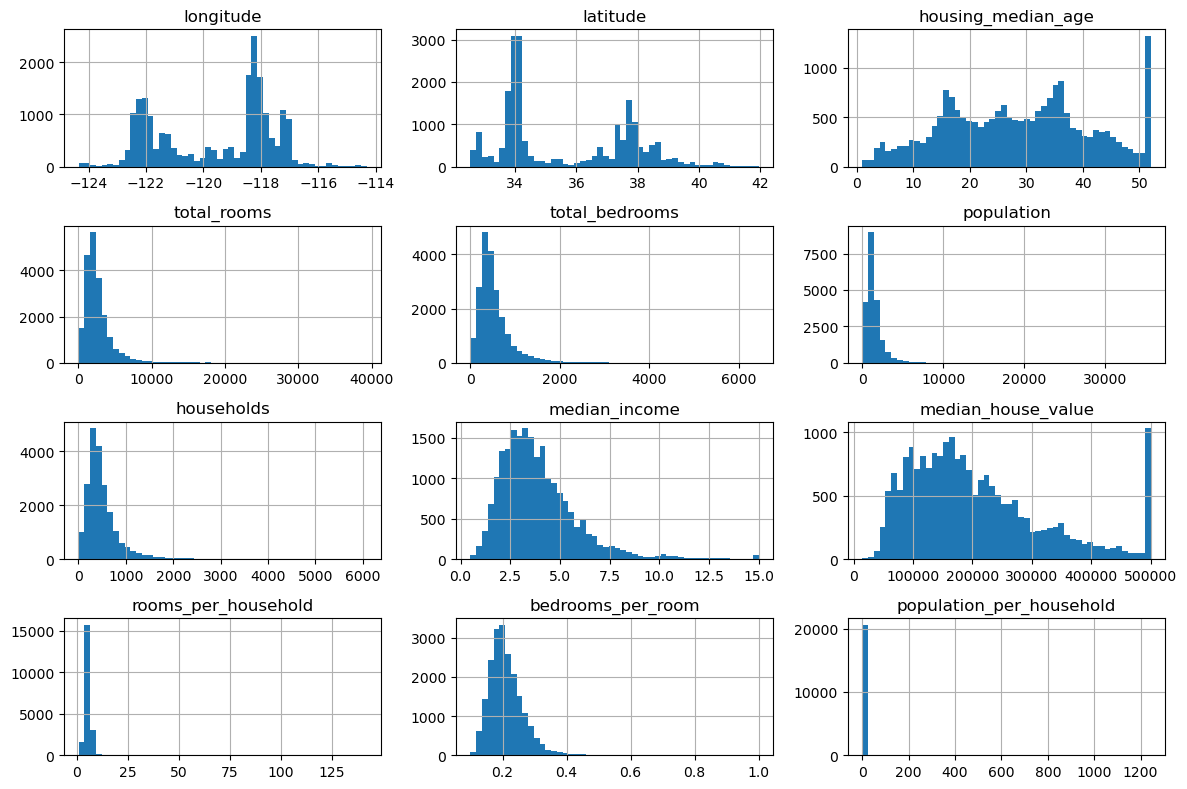

In [68]:
# Step 6: Plot a histogram for every numeric column to understand how the values are spread

housing.hist(
    bins=50,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()


In [69]:
# Step 7: Split the data into training (80%) and testing (20%) sets
# The split uses income categories so both sets have a similar income distribution

split = StratifiedShuffleSplit(test_size=0.2,random_state=42,n_splits=1)
for train_index,test_index in split.split(housing,housing["income_cat"]):
    train_set = housing.iloc[train_index]
    test_set = housing.iloc[test_index]

# Training set: x = input features, y = target (house price)
# We drop the target column and the helper column 'income_cat' from the features
    
x = train_set.drop(["median_house_value","income_cat"],axis=1)
y = train_set["median_house_value"]

# Testing set: same structure, used only to check the model on unseen data

x_test = test_set.drop(["median_house_value","income_cat"],axis=1)
y_test = test_set["median_house_value"]

In [70]:
# Step 8: Separate the columns by type, since each type needs different preprocessing
# num_col = numeric columns, obj_col = text (categorical) columns

num_col = x.select_dtypes(include=["int","float"]).columns
obj_col = x.select_dtypes(include=["object"]).columns


In [71]:
# Step 9: Build preprocessing pipelines
# Numeric columns: scale values to a common range and fill missing values with the median
# Text columns: convert categories into numbers using one-hot encoding

num_pipeline = Pipeline(
    [('scaler',StandardScaler()),
     ("imputer",SimpleImputer(strategy="median"))])
obj_pipeline = Pipeline(
    [('encoder',OneHotEncoder())]) 

In [72]:
# Step 10: Combine both pipelines so each one is applied to the right columns

preprocessor = ColumnTransformer([("num",num_pipeline,num_col),
                                   ("obj",obj_pipeline,obj_col)])


In [73]:
# Step 11: Create the model - a Random Forest Regressor (random_state keeps results the same every run)

model_RFR = RandomForestRegressor(random_state=42)

In [74]:
# Step 12: Join preprocessing and the model into one pipeline
# so raw data can go in and predictions come out

model_pipeline = Pipeline([('preprocessor',preprocessor),
                           ('model',model_RFR)])

In [75]:
# Step 13: Train the model on the training data
print("model training started\n")
model_pipeline.fit(x,y)
print("training complete\n")

model training started

training complete



In [76]:
# Step 14: Use the trained model to predict house prices for the test set

prediction = model_pipeline.predict(x_test)
prediction

array([226401.  , 336784.04,  76936.  , ..., 252370.  , 215805.  ,
       201661.  ], shape=(4128,))

In [77]:
# Step 15: Evaluate the model
# R2   -> how much of the price variation the model explains (closer to 1 is better)
# MAE  -> average prediction error in dollars (lower is better)
# RMSE -> like MAE but penalises large errors more (lower is better)

r2 = r2_score(y_test,prediction)
mae = mean_absolute_error(y_test,prediction)
rmse = np.sqrt(mean_squared_error(y_test,prediction))

print(f"R² Score : {r2:.4f}")
print(f"MAE      : ${mae:,.2f}")
print(f"RMSE     : ${rmse:,.2f}")

R² Score : 0.8137
MAE      : $32,331.02
RMSE     : $49,961.68


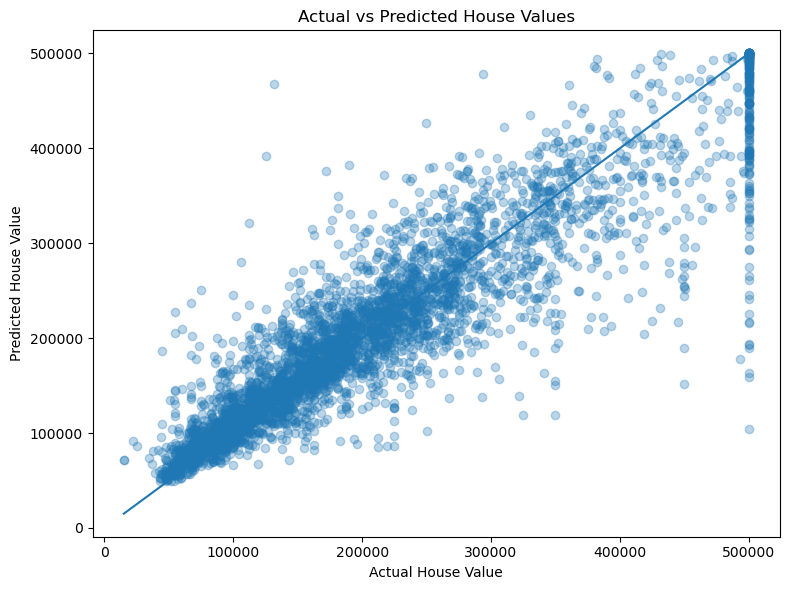

In [79]:
# Step 16: Plot actual vs predicted house values
# Points close to the line mean accurate predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    prediction,
    alpha=0.3
)

# Reference line: points on this line = perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.tight_layout()
plt.show()
